In [2]:
# Proposed Bouc-Wenn Model 


# Proposed Bouc-Wenn Model
$$ 
\Phi_S(x, t) =
\begin{cases}
\frac{\alpha_{x1}x^4(t) + \alpha_{x2}x(t) + (\alpha_{x1}x^4(t) + \alpha_{x2}x(t) - 1)e^{-2x(t)}}{1 + e^{-2x(t)}} + \alpha_z z(t), & x(t) \ge 0 \\[10pt]
0, & x(t) < 0
\end{cases}
$$
Where internal state $z$ is described by below equation
$$
\dot{z} = \left|\dot{x}(t) \right|\left[ A\text{sgn}(\dot{x}(t)) - v|z(t)|^{n-1} + \rho \right]
$$


In [4]:
import numpy as np  
import matplotlib.pyplot as plt 

In [112]:
# List of parameters
global alpha_x1, alpha_x2, alpha_z, A, n, v, rho
alpha_x1 = -0.082
alpha_x2 = 9.886
alpha_z  = -3.09
A = 2.981
n =1.035
v = 2.178
rho = -0.428


In [113]:
def signum(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

def bouc_wenn_model(x, z):
    if (np.sign(x) >= 0):
        return (alpha_x1 * np.power(x, 4) + alpha_x2 * x + (alpha_x1 * np.power(x, 4) + alpha_x2 * x - 1) * np.exp(-2 * x)) / (1 + np.exp(-2 * x)) + alpha_z * z
    else:
        return 0

def internal_state_acceleration(dx, z):
    return np.abs(dx) * (A * np.sign(dx) - v * np.power(np.abs(z), n-1) * z + rho)


In [114]:
# Let's try signum function
x_values = np.linspace(-10, 10, 100)
signum_values = [signum(x) for x in x_values]
print(signum_values)

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


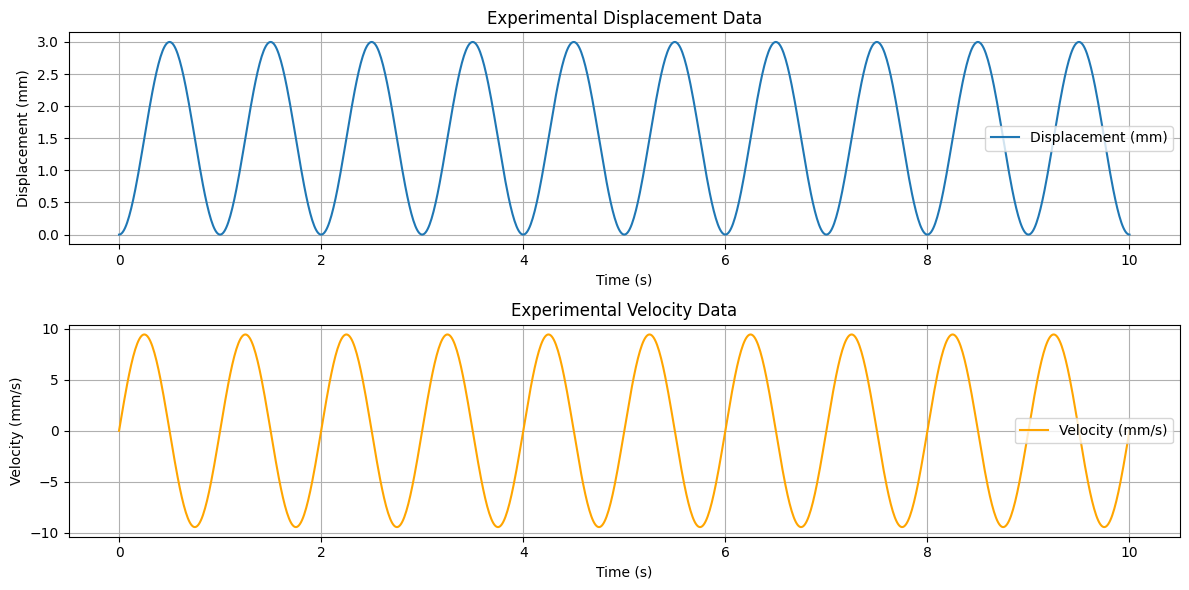

In [115]:
# Experimental data for testing the model
# Sine wave input with peak to peak amplitude of 3 mm displacement and frequency of 1Hz
time = np.linspace(0, 10, 1000)  # Time vector from 0 to 10 seconds
displacement = 1.5 - 1.5 * np.cos(2 * np.pi * 1 * time)  # Displacement in mm
velocity = 2 * np.pi * 1 * 1.5 * np.sin(2 * np.pi * 1 * time)  # Velocity in mm/s
# Display the experimental data
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, displacement, label='Displacement (mm)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)') 
plt.title('Experimental Displacement Data') 
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time, velocity, label='Velocity (mm/s)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (mm/s)')
plt.title('Experimental Velocity Data')
plt.grid()  
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
# Calculate elongation
elongation = np.zeros_like(displacement)
z = np.zeros_like(displacement)
for i in range(len(time)):
    x = displacement[i]
    dx = velocity[i]
    if (i == 0):
        dz = internal_state_acceleration(dx, 0)
        elongation[i] = bouc_wenn_model(x, 0)
    else:
        dz = internal_state_acceleration(dx, z[i-1])
        z[i] += dz * (time[1] - time[0])  # Update internal state using Euler's method
        elongation[i] = bouc_wenn_model(x, z[i-1])
for i in range(0, len(time), 5):  # Print every 5th data point
    print(f"Time: {time[i]:.2f}, \tDisplacement: {displacement[i]:.2f}, \tVelocity: {velocity[i]:.2f}, \tElongation: {elongation[i]:.2f}, \tInternal State: {z[i]:.2f}")

Time: 0.00, 	Displacement: 0.00, 	Velocity: 0.00, 	Elongation: -0.50, 	Internal State: 0.00
Time: 0.05, 	Displacement: 0.07, 	Velocity: 2.92, 	Elongation: 0.08, 	Internal State: 0.07
Time: 0.10, 	Displacement: 0.29, 	Velocity: 5.54, 	Elongation: 2.11, 	Internal State: 0.13
Time: 0.15, 	Displacement: 0.62, 	Velocity: 7.63, 	Elongation: 5.38, 	Internal State: 0.17
Time: 0.20, 	Displacement: 1.04, 	Velocity: 8.97, 	Elongation: 9.47, 	Internal State: 0.19
Time: 0.25, 	Displacement: 1.50, 	Velocity: 9.42, 	Elongation: 13.76, 	Internal State: 0.20
Time: 0.30, 	Displacement: 1.97, 	Velocity: 8.96, 	Elongation: 17.59, 	Internal State: 0.19
Time: 0.35, 	Displacement: 2.38, 	Velocity: 7.61, 	Elongation: 20.38, 	Internal State: 0.17
Time: 0.40, 	Displacement: 2.72, 	Velocity: 5.52, 	Elongation: 21.96, 	Internal State: 0.13
Time: 0.45, 	Displacement: 2.93, 	Velocity: 2.89, 	Elongation: 22.66, 	Internal State: 0.07
Time: 0.50, 	Displacement: 3.00, 	Velocity: -0.03, 	Elongation: 22.97, 	Internal Sta

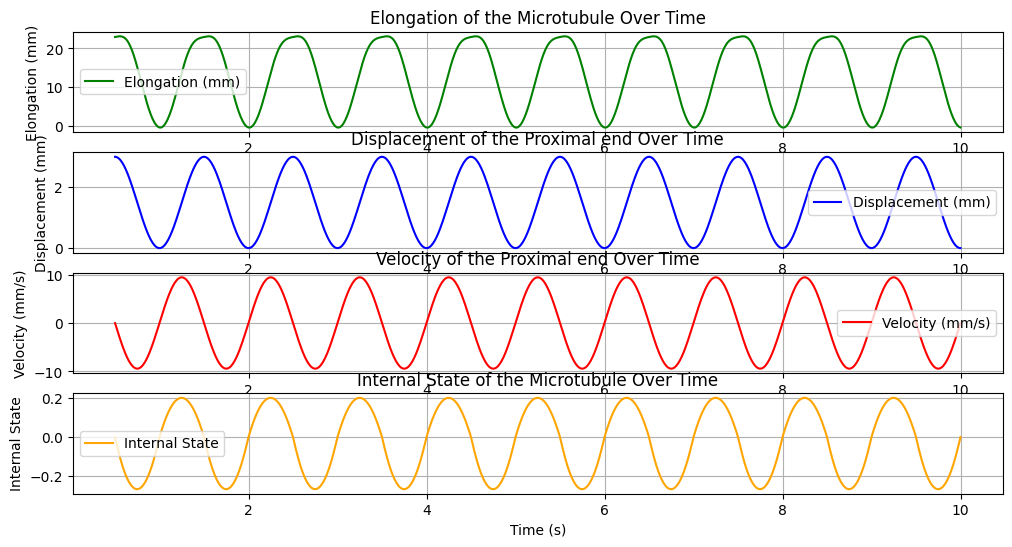

In [117]:
# Display the elongation results
plt.figure(figsize=(12, 6))
plt.subplot(4, 1, 1)
plt.plot(time[50:], elongation[50:], label='Elongation (mm)', color='green')
plt.xlabel('Time (s)')
plt.ylabel('Elongation (mm)')
plt.title('Elongation of the Microtubule Over Time')
plt.grid()
plt.legend()
plt.subplot(4, 1, 2)
plt.plot(time[50:], displacement[50:], label='Displacement (mm)', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)')
plt.title('Displacement of the Proximal end Over Time')
plt.grid()
plt.legend()
plt.subplot(4, 1, 3)
plt.plot(time[50:], velocity[50:], label='Velocity (mm/s)', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (mm/s)')
plt.title('Velocity of the Proximal end Over Time')
plt.grid()
plt.legend()
plt.subplot(4, 1, 4)
plt.plot(time[50:], z[50:], label='Internal State', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Internal State')
plt.title('Internal State of the Microtubule Over Time')
plt.grid()
plt.legend()
plt.show()


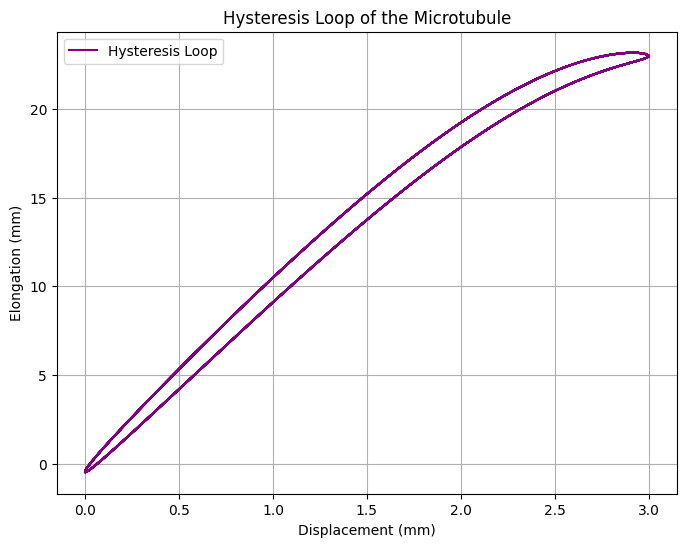

In [118]:
# Plot the hysteresis loop (Elongation vs Displacement)
plt.figure(figsize=(8, 6))
plt.plot(displacement, elongation, label='Hysteresis Loop', color='purple')
plt.xlabel('Displacement (mm)')
plt.ylabel('Elongation (mm)')
plt.title('Hysteresis Loop of the Microtubule')
plt.grid()
plt.legend()
plt.show()